In [27]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [2]:
rfm_scaled_df = pd.read_csv("rfm_for_model.csv")
rfm_original = pd.read_csv("rfm_original_values.csv")

### Kmeans

In [3]:
for k in range(2, 6): # Silhouette score needs at least 2 clusters
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = model.fit_predict(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, labels)
    print(f"Silhouette Score for K={k}: {score:.4f}")

Silhouette Score for K=2: 0.6231
Silhouette Score for K=3: 0.5890
Silhouette Score for K=4: 0.5701
Silhouette Score for K=5: 0.5636


In [4]:
# Calculate Inertia for a range of K values
inertia = []
range_k = range(1, 11) # Checking from 1 to 10 clusters

for k in range_k:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

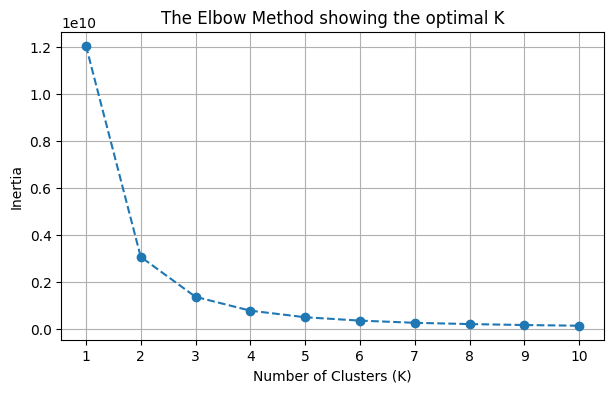

In [5]:
# Plot the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(range_k, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal K')
plt.xticks(range_k)
plt.grid(True)
plt.show()

In [6]:
# 1. Use the ORIGINAL (unscaled) RFM data loaded from  CSV
rfm_log = np.log1p(rfm_original[['Recency', 'Frequency', 'Monetary']])

# 2. Scaling (This creates a NumPy array)
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

# 3. CONVERT BACK TO DATAFRAME (This fixes the 'Cluster' assignment error)
rfm_scaled_final = pd.DataFrame(rfm_scaled_array, 
                                index=rfm_original.index, 
                                columns=['Recency', 'Frequency', 'Monetary'])

# 4. Check for any NaNs created by Log (Safety Check)
rfm_scaled_final.dropna(inplace=True)

# 5. Fit K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
rfm_original['Cluster'] = kmeans.fit_predict(rfm_scaled_final)

# 6. Check the results (using original values so it makes sense to humans)
print(rfm_original.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

            Recency  Frequency     Monetary
Cluster                                    
0        183.643621   1.360656   280.242239
1         14.553699   9.669451  2546.135955
2         88.489778   3.906667  1246.887069
3         17.322931   2.147897   475.760516


In [7]:
type(rfm_scaled_df)

pandas.core.frame.DataFrame

In [8]:
print(rfm_scaled_df.isnull().sum())

print(np.isinf(rfm_scaled_df).values.sum())

customerid    0
Recency       0
Frequency     0
Monetary      0
dtype: int64
0


## Visualizations

In [9]:
rfm_original.columns

Index(['customerid', 'Recency', 'Frequency', 'Monetary', 'Cluster'], dtype='object')

In [10]:
rfm_scaled_final.reset_index().columns

Index(['index', 'Recency', 'Frequency', 'Monetary'], dtype='object')

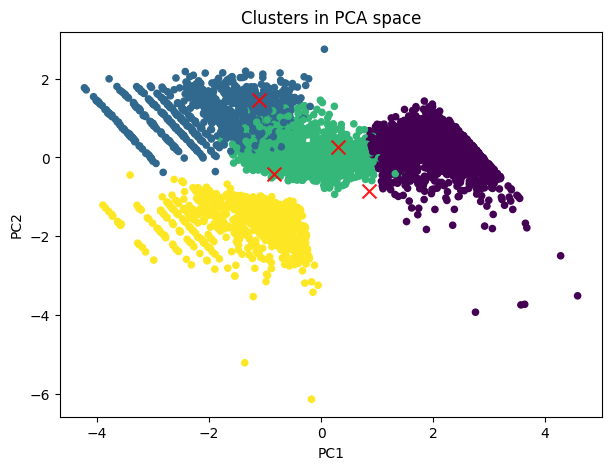

In [26]:
# Reduce to 2D
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_log)

# Scatter with cluster labels
plt.figure(figsize=(7,5))
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c=kmeans.labels_, s=20, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            marker='x', c='red', s=100, alpha=0.9)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA space")
plt.show()


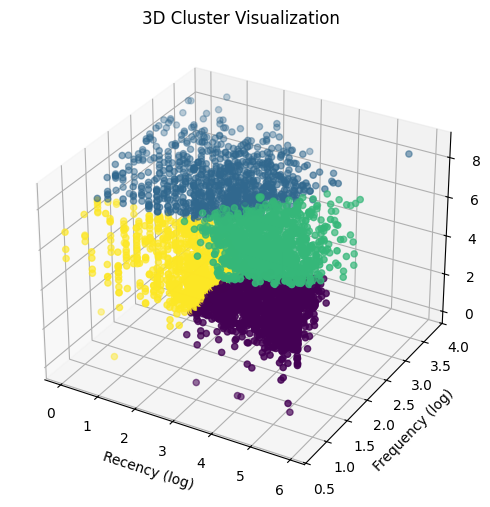

In [19]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm_log['Recency'], rfm_log['Frequency'], rfm_log['Monetary'],
           c=kmeans.labels_, s=20, cmap='viridis')

ax.set_xlabel("Recency (log)")
ax.set_ylabel("Frequency (log)")
ax.set_zlabel("Monetary (log)")
plt.title("3D Cluster Visualization")
plt.show()


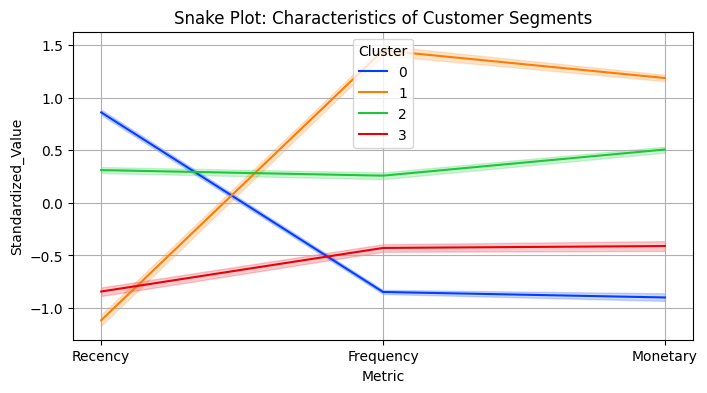

In [11]:
rfm_scaled_final['Cluster'] = rfm_original['Cluster']
rfm_scaled_final['customerid'] = rfm_original['customerid']

rfm_melted = pd.melt(rfm_scaled_final.reset_index(), 
                    id_vars=['customerid', 'Cluster'],
                    value_vars=['Recency', 'Frequency', 'Monetary'], 
                    var_name='Metric', value_name='Standardized_Value')


plt.figure(figsize=(8, 4))
sns.lineplot(data=rfm_melted, x='Metric', y='Standardized_Value', hue='Cluster', palette='bright')
plt.title('Snake Plot: Characteristics of Customer Segments')
plt.grid(True)
plt.show()

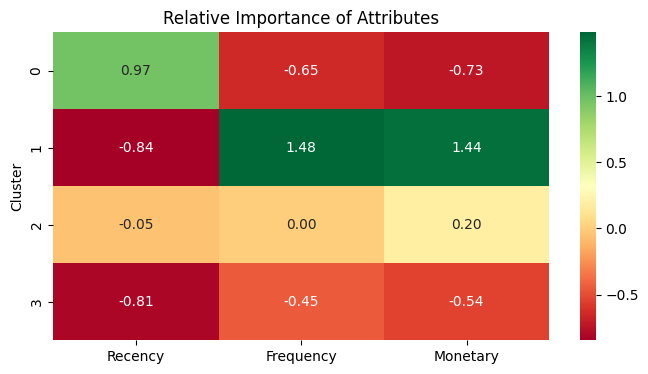

In [24]:
# Calculate relative importance
cluster_avg = rfm_original.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
population_avg = rfm_original[['Recency', 'Frequency', 'Monetary']].mean()
relative_importance = (cluster_avg / population_avg) - 1

plt.figure(figsize=(8, 4))
sns.heatmap(relative_importance, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Relative Importance of Attributes')
plt.show()

### Summary

Cluster 1 - High value, high engagement  
Cluster 0 - Recent but low buyers  
Cluster 2 - Stable buyers  
Cluster 3 - At-risk, low value buyers

In [25]:
rfm_original.to_csv('segmented_customers.csv', index=False)